In [2]:
import torch
import matplotlib.pyplot as plt
from pathlib import Path
import sys
sys.path.insert(0, str(Path.cwd().parent.parent))

In [ ]:
def load_image(path):
    result = torch.load(path, map_location='cpu')
    img = result.generated_image.clamp(0, 1).permute(1, 2, 0).numpy()
    return img, result.fitness_score

attacks_dir = Path('output/attacks')

In [3]:
import math
import matplotlib.image as mpimg

# Must be defined here so torch.load can unpickle Sample objects saved by my_blackbox_attacks.py
class Sample:
    def __init__(self, value, fitness_score=-1):
        self.value = value  # latent w-vector [512], not an image tensor
        self.fitness_score = fitness_score

baseline_attack_root = Path('SMILE-baseline/blackbox_attack/ours-surrogate_model')
baseline_tmp_root    = Path('SMILE-baseline/tmp/blackbox_attack/ours-surrogate_model')

pt_steps = {'original': 'original_w.pt', '500': '500_w.pt', '700': '700_w.pt', 'final': 'final_w.pt'}

for exp_dir in sorted(baseline_attack_root.iterdir()):
    logs_dir = exp_dir / 'LOGS'
    if not logs_dir.exists():
        continue

    # Collect per-target fitness scores (log-softmax → softmax via exp)
    rows = []
    for target_dir in sorted(logs_dir.iterdir(), key=lambda p: int(p.name)):
        idx_dir = target_dir / '0'
        if not idx_dir.exists():
            continue
        scores = {}
        for key, fname in pt_steps.items():
            pt = idx_dir / fname
            if pt.exists():
                s = torch.load(pt, map_location='cpu', weights_only=False)
                scores[key] = math.exp(s.fitness_score)
        rows.append((int(target_dir.name), scores))

    print(f"Experiment: {exp_dir.name}")
    header = f"{'target':>8}" + "".join(f"  {k:>10}" for k in pt_steps)
    print(header)
    for target, scores in rows:
        line = f"{target:>8}" + "".join(f"  {scores.get(k, float('nan')):>10.4f}" for k in pt_steps)
        print(line)

    # Display saved PNG images produced by --test_only run
    candidates = [
        (baseline_tmp_root / f"{exp_dir.name}_og.png",   'generated (no overlay)'),
        (baseline_tmp_root / f"{exp_dir.name}.png",       'generated (confidence overlay)'),
    ]
    available = [(p, t) for p, t in candidates if p.exists()]
    if not available:
        print("  No PNG found — run my_blackbox_attacks.py --test_only to render images.\n")
        continue

    fig, axes = plt.subplots(1, len(available), figsize=(8 * len(available), 10))
    if len(available) == 1:
        axes = [axes]
    for ax, (path, title) in zip(axes, available):
        ax.imshow(mpimg.imread(str(path)))
        ax.set_title(title, fontsize=10)
        ax.axis('off')
    plt.suptitle(exp_dir.name, fontsize=8)
    plt.tight_layout()
    plt.show()
    print()

Experiment: inception_resnetv1_vggface2-celeba_partial256-NGOpt-2500-2500-SMILE-400-0.2-inception_resnetv1_casia-vggface2->CASIA-3
  target    original         500         700       final
       1      0.4469      0.7013      0.7013      0.7013
       2      0.4349      0.7691      0.6613      0.6609
       3      0.0008      0.0041      0.0041      0.0044
       4      0.0231      0.2974      0.3589      0.3595
       5      0.0023      0.0125      0.0141      0.0221
       6      0.4004      0.8930      0.8930      0.8930
       7      0.0164      0.0818      0.1457      0.1477
       8      0.0138      0.0221      0.0282      0.0397
       9      0.8817      0.9631      0.9631      0.9631
      10      0.0420      0.1078      0.2104      0.2104
  No PNG found — run my_blackbox_attacks.py --test_only to render images.



## Whitebox attacks

/home/ken/.conda/envs/SMIRK/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


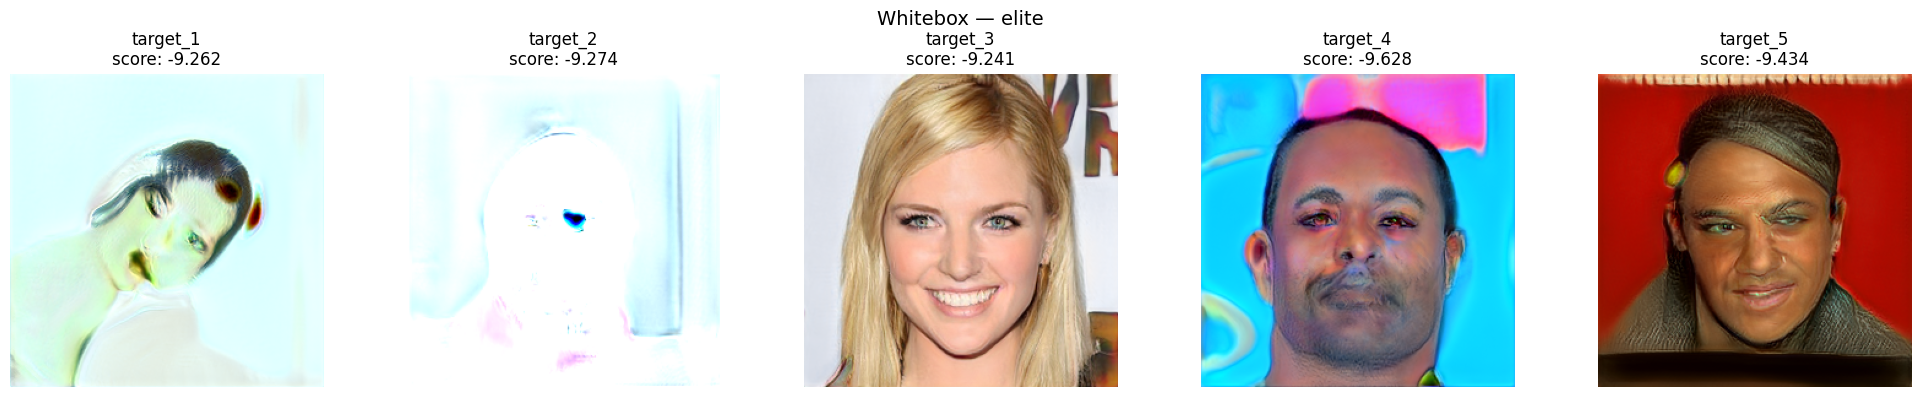

In [4]:
wb_targets = sorted((attacks_dir / 'whitebox').iterdir())
fig, axes = plt.subplots(1, len(wb_targets), figsize=(4 * len(wb_targets), 4))
if len(wb_targets) == 1:
    axes = [axes]
for ax, target_dir in zip(axes, wb_targets):
    img, score = load_image(target_dir / 'elite.pt')
    ax.imshow(img)
    ax.set_title(f"{target_dir.name}\nscore: {score:.3f}")
    ax.axis('off')
plt.suptitle('Whitebox — elite', fontsize=14)
plt.tight_layout()
plt.show()

## Blackbox attacks

RuntimeError: permute(sparse_coo): number of dimensions in the tensor input does not match the length of the desired ordering of dimensions i.e. input.dim() = 4 is not equal to len(dims) = 3

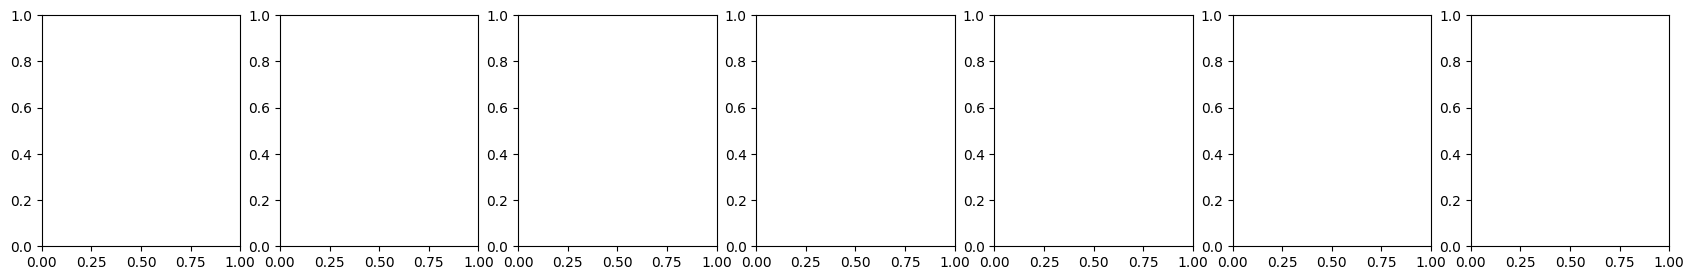

In [5]:
bb_targets = sorted((attacks_dir / 'blackbox').iterdir())
steps = ['original', '0', '500', '1000', '1500', '2000', 'final']

for target_dir in bb_targets:
    files = [target_dir / f'{s}.pt' for s in steps if (target_dir / f'{s}.pt').exists()]
    fig, axes = plt.subplots(1, len(files), figsize=(3 * len(files), 3))
    if len(files) == 1:
        axes = [axes]
    for ax, f in zip(axes, files):
        img, score = load_image(f)
        ax.imshow(img)
        ax.set_title(f"{f.stem}\n{score:.3f}")
        ax.axis('off')
    plt.suptitle(f'Blackbox — {target_dir.name}', fontsize=13)
    plt.tight_layout()
    plt.show()